<a href="https://colab.research.google.com/github/bhanu613/alias-aware-technical-skill-extraction/blob/main/notebooks/04%20Final%20Evaluation%20and%20Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluating Alias-Aware Matching for Technical-Skill Extraction

## Final Evaluation and Results

This notebook evaluates two frozen lexicon-based extractors on the same data.

System A and B matches forms as defined: canonical and canonical+alias respectively.

### **Evaluation Inputs**

The final comparison uses fixed project artifacts.

| Input | Role in the evaluation |
|---|---|
| Evaluation documents | The 100 held-out English job descriptions processed by both systems |
| Final gold annotations | The frozen human reference labels used to score predictions |
| Final lexicon | The 20 canonical technical-skill labels and 13 reviewed aliases |
| Safety and integration evidence | Records that the frozen matcher was tested before held-out scoring |
| Residual error decisions | Source-based explanations for the remaining System B misses |





The notebook loads the frozen evaluation data, gold annotations, and lexicon;
generates predictions for both systems; calculates document-level and
micro-averaged metrics; examines recovered and residual errors; estimates
paired bootstrap confidence intervals; and regenerates the final figures.

In [1]:
from pathlib import Path

import json
import os
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


print("Python packages imported successfully.")

Python packages imported successfully.


In [2]:
import subprocess
import sys


repositoryUrl = (
    "https://github.com/bhanu613/"
    "alias-aware-technical-skill-extraction.git"
)

repositoryFolder = Path(
    "/content/alias-aware-technical-skill-extraction"
)


if not repositoryFolder.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            repositoryUrl,
            str(repositoryFolder)
        ],
        check=True
    )


os.chdir(
    repositoryFolder
)


requirementsPath = (
    repositoryFolder
    / "requirements.txt"
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirementsPath)
    ],
    check=True
)


dataFolder = (
    repositoryFolder
    / "data"
)

configFolder = (
    repositoryFolder
    / "config"
)

resultsFolder = (
    repositoryFolder
    / "results"
)

runtimeFolder = Path(
    "/content/evaluationOutputs"
)

figureFolder = (
    runtimeFolder
    / "figures"
)


figureFolder.mkdir(
    parents=True,
    exist_ok=True
)


print("Repository setup completed.")
print(f"Repository folder: {repositoryFolder}")
print(f"Runtime output folder: {runtimeFolder}")

Repository setup completed.
Repository folder: /content/alias-aware-technical-skill-extraction
Runtime output folder: /content/evaluationOutputs


In [3]:
from matcher import (
    extractSystemA,
    extractSystemB,
    loadLexicon,
    validateLexicon
)


lexiconPath = (
    configFolder
    / "LexiconList20_final.json"
)

evaluationPath = (
    dataFolder
    / "evaluation100.csv"
)

goldPath = (
    dataFolder
    / "goldAnnotationFinal.csv"
)

residualErrorPath = (
    resultsFolder
    / "residual_error_decisions.csv"
)


finalLexicon = loadLexicon(
    lexiconPath
)

skills, canonicalLabels, aliasCount = validateLexicon(
    finalLexicon
)


evaluationData = pd.read_csv(
    evaluationPath
)

goldAnnotations = pd.read_csv(
    goldPath
)

residualErrorRecord = pd.read_csv(
    residualErrorPath
)


print("Frozen evaluation inputs loaded.")
print(f"Evaluation documents: {len(evaluationData)}")
print(f"Gold annotation rows: {len(goldAnnotations)}")
print(f"Canonical labels: {len(canonicalLabels)}")
print(f"Approved aliases: {aliasCount}")
print(
    "Residual System B false-negative instances: "
    f"{len(residualErrorRecord)}"
)

Frozen evaluation inputs loaded.
Evaluation documents: 100
Gold annotation rows: 100
Canonical labels: 20
Approved aliases: 13
Residual System B false-negative instances: 12


## Evaluation Preflight Checks

Before generating predictions, the notebook verifies that the evaluation
documents, gold annotations, lexicon, and residual-error record have the
expected structure and remain aligned.

These checks prevent accidental scoring of the wrong files, invalid labels,
incomplete annotations, or misaligned document identifiers.

In [4]:
requiredEvaluationColumns = {
    "Annotation order",
    "id",
    "Position",
    "Long Description"
}

requiredGoldColumns = {
    "Annotation order",
    "id",
    "Gold skills",
    "Annotation status"
}

requiredResidualColumns = {
    "Annotation order",
    "id",
    "Missed canonical label",
    "System B predictions",
    "Observed wording",
    "Error family"
}


assert requiredEvaluationColumns.issubset(
    evaluationData.columns
), (
    "evaluation100.csv is missing one or more "
    "required columns."
)

assert requiredGoldColumns.issubset(
    goldAnnotations.columns
), (
    "goldAnnotationFinal.csv is missing one or more "
    "required columns."
)

assert requiredResidualColumns.issubset(
    residualErrorRecord.columns
), (
    "residual_error_decisions.csv is missing one or more "
    "required columns."
)


assert len(evaluationData) == 100, (
    f"Expected 100 evaluation documents, "
    f"found {len(evaluationData)}."
)

assert len(goldAnnotations) == 100, (
    f"Expected 100 gold annotation rows, "
    f"found {len(goldAnnotations)}."
)

assert len(residualErrorRecord) == 12, (
    f"Expected 12 residual false-negative instances, "
    f"found {len(residualErrorRecord)}."
)


assert evaluationData["Annotation order"].tolist() == list(
    range(1, 101)
), (
    "Evaluation annotation order must be 1 through 100."
)

assert goldAnnotations["Annotation order"].tolist() == list(
    range(1, 101)
), (
    "Gold annotation order must be 1 through 100."
)


assert evaluationData["id"].is_unique, (
    "Evaluation document identifiers must be unique."
)

assert goldAnnotations["id"].is_unique, (
    "Gold annotation identifiers must be unique."
)


assert evaluationData["id"].tolist() == (
    goldAnnotations["id"].tolist()
), (
    "Evaluation and gold identifiers are not aligned."
)


assert goldAnnotations["Annotation status"].eq(
    "complete"
).all(), (
    "Every released gold annotation row must be complete."
)


assert len(canonicalLabels) == 20, (
    "The frozen lexicon must contain 20 canonical labels."
)

assert aliasCount == 13, (
    "The frozen lexicon must contain 13 approved aliases."
)


print("Evaluation preflight checks passed.")
print("Evaluation and gold identifiers are aligned.")
print("All released gold annotation rows are complete.")
print("The frozen lexicon contains 20 labels and 13 aliases.")

Evaluation preflight checks passed.
Evaluation and gold identifiers are aligned.
All released gold annotation rows are complete.
The frozen lexicon contains 20 labels and 13 aliases.


## Prediction Generation

Both frozen systems process the same 100 held-out job descriptions.

System A searches canonical forms only.

System B searches the same canonical forms and additionally searches the
13 approved aliases.

All predictions are stored as canonical labels. A document with no predicted
in-scope concept is represented by `none`.

In [5]:
def serialiseLabels(labels):

    return "; ".join(
        sorted(labels)
    ) if labels else "none"


def parseLabels(value):

    if pd.isna(value):
        return set()

    cleanedValue = str(value).strip()

    if cleanedValue in {"", "none"}:
        return set()

    return {
        label.strip()
        for label in cleanedValue.split(";")
        if label.strip()
    }


systemAPredictionLists = (
    evaluationData["Long Description"].apply(
        lambda text: extractSystemA(
            text,
            skills
        )
    )
)

systemBPredictionLists = (
    evaluationData["Long Description"].apply(
        lambda text: extractSystemB(
            text,
            skills
        )
    )
)


systemAPredictions = evaluationData[
    [
        "Annotation order",
        "id",
        "Position"
    ]
].copy()

systemBPredictions = evaluationData[
    [
        "Annotation order",
        "id",
        "Position"
    ]
].copy()


systemAPredictions["System A predictions"] = (
    systemAPredictionLists.apply(
        serialiseLabels
    )
)

systemBPredictions["System B predictions"] = (
    systemBPredictionLists.apply(
        serialiseLabels
    )
)


systemAPredictions["System A prediction count"] = (
    systemAPredictionLists.apply(
        len
    )
)

systemBPredictions["System B prediction count"] = (
    systemBPredictionLists.apply(
        len
    )
)


for labels in systemAPredictionLists:

    assert set(labels).issubset(
        canonicalLabels
    ), (
        "System A produced a label outside the "
        "frozen canonical inventory."
    )


for labels in systemBPredictionLists:

    assert set(labels).issubset(
        canonicalLabels
    ), (
        "System B produced a label outside the "
        "frozen canonical inventory."
    )


for labelsA, labelsB in zip(
    systemAPredictionLists,
    systemBPredictionLists
):

    assert set(labelsA).issubset(
        set(labelsB)
    ), (
        "System A predictions must be a subset of "
        "System B predictions for every document."
    )


assert systemAPredictions["id"].tolist() == (
    goldAnnotations["id"].tolist()
), (
    "System A predictions are not aligned with "
    "the frozen gold annotations."
)

assert systemBPredictions["id"].tolist() == (
    goldAnnotations["id"].tolist()
), (
    "System B predictions are not aligned with "
    "the frozen gold annotations."
)


systemANoneCount = int(
    systemAPredictions["System A predictions"].eq(
        "none"
    ).sum()
)

systemBNoneCount = int(
    systemBPredictions["System B predictions"].eq(
        "none"
    ).sum()
)

systemBAdditionalDocumentCount = int(
    sum(
        set(labelsB) != set(labelsA)
        for labelsA, labelsB in zip(
            systemAPredictionLists,
            systemBPredictionLists
        )
    )
)


predictionSummary = pd.DataFrame(
    {
        "System": [
            "System A",
            "System B"
        ],
        "Prediction rows": [
            len(systemAPredictions),
            len(systemBPredictions)
        ],
        "Documents predicted as none": [
            systemANoneCount,
            systemBNoneCount
        ]
    }
)


display(predictionSummary)


print(
    "System A prediction generation completed."
)

print(
    "System B prediction generation completed."
)

print(
    "System A prediction sets are contained in "
    "System B prediction sets."
)

print(
    "Documents where System B added one or more labels: "
    f"{systemBAdditionalDocumentCount}"
)


systemAPredictions.to_csv(
    runtimeFolder / "SystemAPredictions.csv",
    index=False
)

systemBPredictions.to_csv(
    runtimeFolder / "SystemBPredictions.csv",
    index=False
)

,System,Prediction rows,Documents predicted as none
0,System A,100,5
1,System B,100,5


System A prediction generation completed.
System B prediction generation completed.
System A prediction sets are contained in System B prediction sets.
Documents where System B added one or more labels: 55


In [13]:
print(
    "First 10 held-out prediction records"
)

display(
    pd.concat(
        [
            goldAnnotations[
                [
                    "Annotation order",
                    "Position",
                    "Gold skills"
                ]
            ],

            systemAPredictions[
                [
                    "System A predictions"
                ]
            ],

            systemBPredictions[
                [
                    "System B predictions"
                ]
            ]
        ],
        axis=1
    ).head(
        10
    )
)

First 10 held-out prediction records


,Annotation order,Position,Gold skills,System A predictions,System B predictions
0,1,"Backend developer (Python, Golang or C#) Short...",python,python,python
1,2,Data Engineer,python; sql,python; sql,python; sql
2,3,Computer Vision - AI Software Engineer,docker; machine learning; python,python,python
3,4,Senior Data Engineer,amazon web services; apache spark; machine lea...,machine learning; python,amazon web services; apache spark; machine lea...
4,5,Business Application Developer,azure; git; power bi; sql,azure; git; sql,azure; git; power bi; sql
5,6,Fullstack Python/Django/React Developer,python,python,python
6,7,Big Data Engineer,apache spark; machine learning; python; sql,machine learning; python; sql,apache spark; machine learning; python; sql
7,8,Senior Python Backend Engineer - Relocate,amazon web services; docker; git; kubernetes; ...,docker; git; kubernetes; mongodb; postgresql; ...,amazon web services; docker; git; kubernetes; ...
8,9,Python Senior,amazon web services; docker; machine learning;...,docker; machine learning; postgresql; python,amazon web services; docker; machine learning;...
9,10,Python Software Engineer,google cloud platform; mongodb; postgresql; py...,mongodb; postgresql; python; sql,mongodb; postgresql; python; sql


## Document-Level Evaluation

Gold labels and predictions are compared as sets for each document.

A true positive is a predicted canonical label that is also present in the
gold-label set.

A false positive is a predicted canonical label not present in the gold set.

A false negative is a gold canonical label not predicted by the system.

An exact set match occurs when the complete predicted label set is identical
to the complete gold-label set for a document.

In [6]:
def calculateDocumentEvaluation(
    goldLabels,
    predictedLabels
):

    truePositives = (
        goldLabels
        & predictedLabels
    )

    falsePositives = (
        predictedLabels
        - goldLabels
    )

    falseNegatives = (
        goldLabels
        - predictedLabels
    )

    return {
        "TP labels": serialiseLabels(
            truePositives
        ),
        "FP labels": serialiseLabels(
            falsePositives
        ),
        "FN labels": serialiseLabels(
            falseNegatives
        ),
        "TP": len(
            truePositives
        ),
        "FP": len(
            falsePositives
        ),
        "FN": len(
            falseNegatives
        ),
        "Exact set match": (
            goldLabels
            == predictedLabels
        )
    }


goldLabelSets = goldAnnotations[
    "Gold skills"
].apply(
    parseLabels
)


for labels in goldLabelSets:

    assert labels.issubset(
        canonicalLabels
    ), (
        "A gold annotation contains a label outside "
        "the frozen canonical inventory."
    )


systemAEvaluationRows = []

systemBEvaluationRows = []


for goldLabels, labelsA, labelsB in zip(
    goldLabelSets,
    systemAPredictionLists,
    systemBPredictionLists
):

    systemAEvaluationRows.append(
        calculateDocumentEvaluation(
            goldLabels,
            set(labelsA)
        )
    )

    systemBEvaluationRows.append(
        calculateDocumentEvaluation(
            goldLabels,
            set(labelsB)
        )
    )


systemAEvaluation = pd.DataFrame(
    systemAEvaluationRows
).add_prefix(
    "System A "
)

systemBEvaluation = pd.DataFrame(
    systemBEvaluationRows
).add_prefix(
    "System B "
)


documentEvaluation = pd.concat(
    [
        evaluationData[
            [
                "Annotation order",
                "id",
                "Position"
            ]
        ].copy(),

        goldAnnotations[
            [
                "Gold skills"
            ]
        ].copy(),

        systemAPredictions[
            [
                "System A predictions"
            ]
        ].copy(),

        systemBPredictions[
            [
                "System B predictions"
            ]
        ].copy(),

        systemAEvaluation,

        systemBEvaluation
    ],
    axis=1
)


assert len(documentEvaluation) == 100, (
    "Document-level evaluation must contain "
    "exactly 100 rows."
)

assert documentEvaluation["id"].tolist() == (
    goldAnnotations["id"].tolist()
), (
    "Document-level evaluation is not aligned "
    "with frozen gold identifiers."
)


documentEvaluation.to_csv(
    runtimeFolder / "DocumentEvaluation.csv",
    index=False
)


print(
    "Document-level evaluation completed."
)

Document-level evaluation completed.


## Micro-Averaged Metrics

The evaluation pools true positives, false positives, and false negatives
across all document-label decisions before calculating precision, recall, and
F1.

Micro precision answers: of all predicted labels, how many were correct?

Micro recall answers: of all gold labels, how many were recovered?

Micro F1 balances pooled precision and recall.

Exact-set-match rate reports the proportion of documents for which the complete
predicted label set exactly matches the complete gold-label set.

In [7]:
def safeDivide(
    numerator,
    denominator
):

    return (
        numerator / denominator
        if denominator != 0
        else 0.0
    )


def calculateMicroMetrics(
    documentEvaluation,
    systemPrefix
):

    truePositives = int(
        documentEvaluation[
            f"{systemPrefix}TP"
        ].sum()
    )

    falsePositives = int(
        documentEvaluation[
            f"{systemPrefix}FP"
        ].sum()
    )

    falseNegatives = int(
        documentEvaluation[
            f"{systemPrefix}FN"
        ].sum()
    )

    documents = len(
        documentEvaluation
    )

    exactMatchDocuments = int(
        documentEvaluation[
            f"{systemPrefix}Exact set match"
        ].sum()
    )

    return {
        "Documents": documents,
        "True positives": truePositives,
        "False positives": falsePositives,
        "False negatives": falseNegatives,
        "Micro precision": safeDivide(
            truePositives,
            truePositives + falsePositives
        ),
        "Micro recall": safeDivide(
            truePositives,
            truePositives + falseNegatives
        ),
        "Micro F1": safeDivide(
            2 * truePositives,
            (
                2 * truePositives
                + falsePositives
                + falseNegatives
            )
        ),
        "Exact-set-match documents": (
            exactMatchDocuments
        ),
        "Exact-set-match rate": safeDivide(
            exactMatchDocuments,
            documents
        )
    }


totalGoldLabels = sum(
    len(labels)
    for labels in goldLabelSets
)

totalSystemALabels = sum(
    len(labels)
    for labels in systemAPredictionLists
)

totalSystemBLabels = sum(
    len(labels)
    for labels in systemBPredictionLists
)


systemAMetrics = calculateMicroMetrics(
    documentEvaluation,
    "System A "
)

systemBMetrics = calculateMicroMetrics(
    documentEvaluation,
    "System B "
)


metricSummary = pd.DataFrame(
    [
        {
            "System": "System A",
            "Gold label instances": totalGoldLabels,
            "Predicted label instances": totalSystemALabels,
            **systemAMetrics
        },
        {
            "System": "System B",
            "Gold label instances": totalGoldLabels,
            "Predicted label instances": totalSystemBLabels,
            **systemBMetrics
        }
    ]
)


assert (
    systemAMetrics["True positives"]
    + systemAMetrics["False negatives"]
    == totalGoldLabels
), (
    "System A TP + FN must equal all gold labels."
)

assert (
    systemBMetrics["True positives"]
    + systemBMetrics["False negatives"]
    == totalGoldLabels
), (
    "System B TP + FN must equal all gold labels."
)

assert (
    systemAMetrics["True positives"]
    + systemAMetrics["False positives"]
    == totalSystemALabels
), (
    "System A TP + FP must equal all predicted labels."
)

assert (
    systemBMetrics["True positives"]
    + systemBMetrics["False positives"]
    == totalSystemBLabels
), (
    "System B TP + FP must equal all predicted labels."
)


display(
    metricSummary.round(
        {
            "Micro precision": 4,
            "Micro recall": 4,
            "Micro F1": 4,
            "Exact-set-match rate": 4
        }
    )
)


metricSummary.to_csv(
    runtimeFolder / "MetricSummary.csv",
    index=False
)


print(
    "Micro-averaged metrics calculated successfully."
)

,System,Gold label instances,Predicted label instances,Documents,True positives,False positives,False negatives,Micro precision,Micro recall,Micro F1,Exact-set-match documents,Exact-set-match rate
0,System A,379,287,100,287,0,92,1.0,0.7573,0.8619,41,0.41
1,System B,379,367,100,367,0,12,1.0,0.9683,0.9839,89,0.89


Micro-averaged metrics calculated successfully.


In [8]:
expectedMetrics = {
    "System A": {
        "True positives": 287,
        "False positives": 0,
        "False negatives": 92,
        "Micro precision": 1.0000,
        "Micro recall": 0.7573,
        "Micro F1": 0.8619,
        "Exact-set-match documents": 41,
        "Exact-set-match rate": 0.4100
    },
    "System B": {
        "True positives": 367,
        "False positives": 0,
        "False negatives": 12,
        "Micro precision": 1.0000,
        "Micro recall": 0.9683,
        "Micro F1": 0.9839,
        "Exact-set-match documents": 89,
        "Exact-set-match rate": 0.8900
    }
}


for _, row in metricSummary.iterrows():

    systemName = row["System"]

    expected = expectedMetrics[
        systemName
    ]

    for metricName, expectedValue in expected.items():

        observedValue = row[
            metricName
        ]

        if isinstance(
            expectedValue,
            float
        ):
            assert round(
                observedValue,
                4
            ) == expectedValue, (
                f"{systemName} {metricName} differs "
                "from the locked result."
            )
        else:
            assert int(
                observedValue
            ) == expectedValue, (
                f"{systemName} {metricName} differs "
                "from the locked result."
            )


print(
    "Locked held-out metrics reproduced successfully."
)

Locked held-out metrics reproduced successfully.


## Per-Label Recovery Analysis

Overall micro metrics show the total effect of alias-aware matching. This section
shows which canonical labels account for the difference.

For each frozen canonical label, the analysis calculates support, true positives,
false positives, false negatives, and the number of System A false-negative
instances recovered by System B.

In [17]:
def calculateLabelMetrics(
    truePositives,
    falsePositives,
    falseNegatives
):

    precision = safeDivide(
        truePositives,
        truePositives + falsePositives
    )

    recall = safeDivide(
        truePositives,
        truePositives + falseNegatives
    )

    f1 = safeDivide(
        2 * truePositives,
        (
            2 * truePositives
            + falsePositives
            + falseNegatives
        )
    )

    return precision, recall, f1


perLabelRows = []


for canonicalLabel in sorted(
    canonicalLabels
):

    systemATruePositives = 0
    systemAFalsePositives = 0
    systemAFalseNegatives = 0

    systemBTruePositives = 0
    systemBFalsePositives = 0
    systemBFalseNegatives = 0


    for _, row in documentEvaluation.iterrows():

        if canonicalLabel in parseLabels(
            row["System A TP labels"]
        ):
            systemATruePositives += 1

        if canonicalLabel in parseLabels(
            row["System A FP labels"]
        ):
            systemAFalsePositives += 1

        if canonicalLabel in parseLabels(
            row["System A FN labels"]
        ):
            systemAFalseNegatives += 1

        if canonicalLabel in parseLabels(
            row["System B TP labels"]
        ):
            systemBTruePositives += 1

        if canonicalLabel in parseLabels(
            row["System B FP labels"]
        ):
            systemBFalsePositives += 1

        if canonicalLabel in parseLabels(
            row["System B FN labels"]
        ):
            systemBFalseNegatives += 1


    systemAPrecision, systemARecall, systemAF1 = (
        calculateLabelMetrics(
            systemATruePositives,
            systemAFalsePositives,
            systemAFalseNegatives
        )
    )

    systemBPrecision, systemBRecall, systemBF1 = (
        calculateLabelMetrics(
            systemBTruePositives,
            systemBFalsePositives,
            systemBFalseNegatives
        )
    )

    recoveredBySystemB = (
        systemAFalseNegatives
        - systemBFalseNegatives
    )

    goldSupport = (
        systemATruePositives
        + systemAFalseNegatives
    )


    perLabelRows.append(
        {
            "Canonical label": canonicalLabel,
            "Gold support": goldSupport,

            "System A TP": systemATruePositives,
            "System A FP": systemAFalsePositives,
            "System A FN": systemAFalseNegatives,
            "System A precision": systemAPrecision,
            "System A recall": systemARecall,
            "System A F1": systemAF1,

            "System B TP": systemBTruePositives,
            "System B FP": systemBFalsePositives,
            "System B FN": systemBFalseNegatives,
            "System B precision": systemBPrecision,
            "System B recall": systemBRecall,
            "System B F1": systemBF1,

            "Recovered by System B": (
                recoveredBySystemB
            )
        }
    )


perLabelMetrics = pd.DataFrame(
    perLabelRows
).sort_values(
    by=[
        "Gold support",
        "Canonical label"
    ],
    ascending=[
        False,
        True
    ]
).reset_index(
    drop=True
)


assert len(perLabelMetrics) == 20, (
    "Per-label analysis must contain "
    "exactly 20 canonical labels."
)

assert int(
    perLabelMetrics["Gold support"].sum()
) == 379, (
    "Per-label gold support must sum to 379."
)

assert int(
    perLabelMetrics["System A TP"].sum()
) == 287

assert int(
    perLabelMetrics["System A FP"].sum()
) == 0

assert int(
    perLabelMetrics["System A FN"].sum()
) == 92

assert int(
    perLabelMetrics["System B TP"].sum()
) == 367

assert int(
    perLabelMetrics["System B FP"].sum()
) == 0

assert int(
    perLabelMetrics["System B FN"].sum()
) == 12

assert int(
    perLabelMetrics["Recovered by System B"].sum()
) == 80, (
    "Per-label recoveries must sum to 80."
)


totalPerLabelRow = pd.DataFrame(
    [
        {
            "Canonical label": "TOTAL micro aggregate",

            "Gold support": int(
                perLabelMetrics[
                    "Gold support"
                ].sum()
            ),

            "System A TP": int(
                perLabelMetrics[
                    "System A TP"
                ].sum()
            ),

            "System A FP": int(
                perLabelMetrics[
                    "System A FP"
                ].sum()
            ),

            "System A FN": int(
                perLabelMetrics[
                    "System A FN"
                ].sum()
            ),

            "System A precision": systemAMetrics[
                "Micro precision"
            ],

            "System A recall": systemAMetrics[
                "Micro recall"
            ],

            "System A F1": systemAMetrics[
                "Micro F1"
            ],

            "System B TP": int(
                perLabelMetrics[
                    "System B TP"
                ].sum()
            ),

            "System B FP": int(
                perLabelMetrics[
                    "System B FP"
                ].sum()
            ),

            "System B FN": int(
                perLabelMetrics[
                    "System B FN"
                ].sum()
            ),

            "System B precision": systemBMetrics[
                "Micro precision"
            ],

            "System B recall": systemBMetrics[
                "Micro recall"
            ],

            "System B F1": systemBMetrics[
                "Micro F1"
            ],

            "Recovered by System B": int(
                perLabelMetrics[
                    "Recovered by System B"
                ].sum()
            )
        }
    ]
)


perLabelDisplay = pd.concat(
    [
        perLabelMetrics,
        totalPerLabelRow
    ],
    ignore_index=True
)


display(
    perLabelDisplay.round(
        {
            "System A precision": 4,
            "System A recall": 4,
            "System A F1": 4,
            "System B precision": 4,
            "System B recall": 4,
            "System B F1": 4
        }
    )
)


perLabelMetrics.to_csv(
    runtimeFolder / "PerLabelMetrics.csv",
    index=False
)


print(
    "Per-label recovery analysis completed."
)

print(
    "System A misses: 92"
)

print(
    "Recovered by System B: 80"
)

print(
    "Residual System B misses: 12"
)

,Canonical label,Gold support,System A TP,System A FP,System A FN,System A precision,System A recall,System A F1,System B TP,System B FP,System B FN,System B precision,System B recall,System B F1,Recovered by System B
0,python,83,83,0,0,1.0,1.0000,1.0000,83,0,0,1.0,1.0000,1.0000,0
1,sql,44,44,0,0,1.0,1.0000,1.0000,44,0,0,1.0,1.0000,1.0000,0
2,amazon web services,33,3,0,30,1.0,0.0909,0.1667,33,0,0,1.0,1.0000,1.0000,30
3,machine learning,33,25,0,8,1.0,0.7576,0.8621,32,0,1,1.0,0.9697,0.9846,7
4,postgresql,28,23,0,5,1.0,0.8214,0.9020,27,0,1,1.0,0.9643,0.9818,4
5,docker,20,18,0,2,1.0,0.9000,0.9474,18,0,2,1.0,0.9000,0.9474,0
6,google cloud platform,20,3,0,17,1.0,0.1500,0.2609,15,0,5,1.0,0.7500,0.8571,12
7,git,19,19,0,0,1.0,1.0000,1.0000,19,0,0,1.0,1.0000,1.0000,0
8,azure,16,16,0,0,1.0,1.0000,1.0000,16,0,0,1.0,1.0000,1.0000,0
9,mongodb,14,12,0,2,1.0,0.8571,0.9231,13,0,1,1.0,0.9286,0.9630,1


Per-label recovery analysis completed.
System A misses: 92
Recovered by System B: 80
Residual System B misses: 12


## Document Recovery and Residual Errors

System A missed 92 gold-label instances. System B recovered 80 of those
instances and still missed 12.

The remaining System B misses are examined descriptively using the frozen
residual error-decision record. This error analysis records limitations of the
evaluated system; it does not change the lexicon, matcher, gold annotations,
or reported metrics.

In [10]:
recoveryRows = []


for _, row in documentEvaluation.iterrows():

    systemAMissedLabels = parseLabels(
        row["System A FN labels"]
    )

    systemBMissedLabels = parseLabels(
        row["System B FN labels"]
    )

    recoveredLabels = (
        systemAMissedLabels
        - systemBMissedLabels
    )

    recoveryRows.append(
        {
            "Annotation order": row[
                "Annotation order"
            ],
            "id": row["id"],
            "Position": row["Position"],

            "System A missed labels": serialiseLabels(
                systemAMissedLabels
            ),

            "Recovered by System B": serialiseLabels(
                recoveredLabels
            ),

            "System B residual missed labels": (
                serialiseLabels(
                    systemBMissedLabels
                )
            )
        }
    )


recoveryAudit = pd.DataFrame(
    recoveryRows
)


recoveredInstanceCount = sum(
    len(
        parseLabels(value)
    )
    for value in recoveryAudit[
        "Recovered by System B"
    ]
)

residualInstanceCount = sum(
    len(
        parseLabels(value)
    )
    for value in recoveryAudit[
        "System B residual missed labels"
    ]
)

recoveryDocumentCount = int(
    recoveryAudit[
        "Recovered by System B"
    ].ne(
        "none"
    ).sum()
)

residualDocumentCount = int(
    recoveryAudit[
        "System B residual missed labels"
    ].ne(
        "none"
    ).sum()
)


assert recoveredInstanceCount == 80, (
    "Recovered label instances must equal 80."
)

assert residualInstanceCount == 12, (
    "Residual label instances must equal 12."
)

assert recoveryDocumentCount == 55, (
    "Recovery documents must equal 55."
)

assert residualDocumentCount == 11, (
    "Residual-error documents must equal 11."
)


residualPairs = set(
    zip(
        residualErrorRecord[
            "Annotation order"
        ],
        residualErrorRecord[
            "Missed canonical label"
        ]
    )
)

auditResidualPairs = set()


for _, row in recoveryAudit.iterrows():

    for missedLabel in parseLabels(
        row[
            "System B residual missed labels"
        ]
    ):
        auditResidualPairs.add(
            (
                row["Annotation order"],
                missedLabel
            )
        )


assert residualPairs == auditResidualPairs, (
    "The residual decision record does not match "
    "the evaluated System B false-negative instances."
)


recoveryAudit.to_csv(
    runtimeFolder / "RecoveryAudit.csv",
    index=False
)


recoverySummary = pd.DataFrame(
    {
        "Measure": [
            "System A false-negative instances",
            "Recovered by System B",
            "Residual System B false-negative instances",
            "Recovery documents",
            "Residual-error documents"
        ],
        "Value": [
            92,
            recoveredInstanceCount,
            residualInstanceCount,
            recoveryDocumentCount,
            residualDocumentCount
        ]
    }
)


display(
    recoverySummary
)


print(
    "Recovery audit and residual-record alignment passed."
)

,Measure,Value
0,System A false-negative instances,92
1,Recovered by System B,80
2,Residual System B false-negative instances,12
3,Recovery documents,55
4,Residual-error documents,11


Recovery audit and residual-record alignment passed.


In [20]:
recoveryDisplay = perLabelMetrics.loc[
    perLabelMetrics[
        "Recovered by System B"
    ] > 0,
    [
        "Canonical label",
        "Gold support",
        "System A FN",
        "System B FN",
        "Recovered by System B"
    ]
].sort_values(
    "Recovered by System B",
    ascending=False
).reset_index(drop=True)


display(
    recoveryDisplay
)

,Canonical label,Gold support,System A FN,System B FN,Recovered by System B
0,amazon web services,33,30,0,30
1,google cloud platform,20,17,5,12
2,apache spark,11,8,0,8
3,machine learning,33,8,1,7
4,apache kafka,5,5,0,5
5,postgresql,28,5,1,4
6,power bi,8,4,0,4
7,natural language processing,8,3,0,3
8,apache airflow,4,3,0,3
9,kubernetes,11,3,1,2


In [21]:
systemAMissPreview = recoveryAudit.loc[
    recoveryAudit[
        "System A missed labels"
    ].ne(
        "none"
    ),
    [
        "Annotation order",
        "Position",
        "System A missed labels"
    ]
].head(
    10
).reset_index(drop=True)


systemBRecoveryPreview = recoveryAudit.loc[
    recoveryAudit[
        "Recovered by System B"
    ].ne(
        "none"
    ),
    [
        "Annotation order",
        "Position",
        "Recovered by System B"
    ]
].head(
    10
).reset_index(drop=True)


systemBResidualPreview = recoveryAudit.loc[
    recoveryAudit[
        "System B residual missed labels"
    ].ne(
        "none"
    ),
    [
        "Annotation order",
        "Position",
        "System B residual missed labels"
    ]
].head(
    10
).reset_index(drop=True)


print(
    "First 10 System A false-negative documents"
)

display(
    systemAMissPreview
)


print(
    "First 10 documents with labels recovered by System B"
)

display(
    systemBRecoveryPreview
)


print(
    "Residual System B false-negative documents"
)

display(
    systemBResidualPreview
)

First 10 System A false-negative documents


,Annotation order,Position,System A missed labels
0,3,Computer Vision - AI Software Engineer,docker; machine learning
1,4,Senior Data Engineer,amazon web services; apache spark
2,5,Business Application Developer,power bi
3,7,Big Data Engineer,apache spark
4,8,Senior Python Backend Engineer - Relocate,amazon web services
5,9,Python Senior,amazon web services
6,10,Python Software Engineer,google cloud platform
7,11,Analyst BPM-system,postgresql
8,12,Full-stack Developer (Python 80% and FE( React...,amazon web services
9,13,Senior Python Developer (with DevOps),amazon web services; elasticsearch


First 10 documents with labels recovered by System B


,Annotation order,Position,Recovered by System B
0,4,Senior Data Engineer,amazon web services; apache spark
1,5,Business Application Developer,power bi
2,7,Big Data Engineer,apache spark
3,8,Senior Python Backend Engineer - Relocate,amazon web services
4,9,Python Senior,amazon web services
5,11,Analyst BPM-system,postgresql
6,12,Full-stack Developer (Python 80% and FE( React...,amazon web services
7,13,Senior Python Developer (with DevOps),amazon web services
8,14,Data Developer,apache kafka
9,16,Middle Python Engineer,amazon web services


Residual System B false-negative documents


,Annotation order,Position,System B residual missed labels
0,3,Computer Vision - AI Software Engineer,docker; machine learning
1,10,Python Software Engineer,google cloud platform
2,13,Senior Python Developer (with DevOps),elasticsearch
3,18,Middle Python Backend Developer,docker
4,44,Backend Engineer,google cloud platform
5,54,Middle Python Developer,google cloud platform
6,71,Database Administrator,postgresql
7,88,Senior Python developer (with AWS /Azure/Googl...,google cloud platform
8,95,Data Engineer,kubernetes
9,96,Backend Engineer,mongodb


## Paired Bootstrap Uncertainty Analysis

The same sampled document indices are used for both systems in each bootstrap
replicate. This preserves the paired comparison between System A and System B.

The analysis uses 10,000 paired non-parametric document bootstrap replicates,
random seed 20260918, and percentile 95% confidence intervals.

In [11]:
bootstrapRandomGenerator = np.random.default_rng(
    20260918
)

bootstrapRows = []

numberOfReplicates = 10_000


for _ in range(
    numberOfReplicates
):

    sampledIndices = bootstrapRandomGenerator.integers(
        low=0,
        high=len(documentEvaluation),
        size=len(documentEvaluation)
    )

    sampledEvaluation = documentEvaluation.iloc[
        sampledIndices
    ]

    sampledSystemAMetrics = calculateMicroMetrics(
        sampledEvaluation,
        "System A "
    )

    sampledSystemBMetrics = calculateMicroMetrics(
        sampledEvaluation,
        "System B "
    )

    bootstrapRows.append(
        {
            "Micro recall difference": (
                sampledSystemBMetrics[
                    "Micro recall"
                ]
                - sampledSystemAMetrics[
                    "Micro recall"
                ]
            ),

            "Micro F1 difference": (
                sampledSystemBMetrics[
                    "Micro F1"
                ]
                - sampledSystemAMetrics[
                    "Micro F1"
                ]
            ),

            "Exact-set-match-rate difference": (
                sampledSystemBMetrics[
                    "Exact-set-match rate"
                ]
                - sampledSystemAMetrics[
                    "Exact-set-match rate"
                ]
            )
        }
    )


bootstrapDifferences = pd.DataFrame(
    bootstrapRows
)


bootstrapSummary = pd.DataFrame(
    {
        "Metric difference": [
            "Micro recall",
            "Micro F1",
            "Exact-set-match rate"
        ],

        "Point estimate": [
            (
                systemBMetrics[
                    "Micro recall"
                ]
                - systemAMetrics[
                    "Micro recall"
                ]
            ),

            (
                systemBMetrics[
                    "Micro F1"
                ]
                - systemAMetrics[
                    "Micro F1"
                ]
            ),

            (
                systemBMetrics[
                    "Exact-set-match rate"
                ]
                - systemAMetrics[
                    "Exact-set-match rate"
                ]
            )
        ],

        "95% CI lower": [
            np.percentile(
                bootstrapDifferences[
                    "Micro recall difference"
                ],
                2.5
            ),

            np.percentile(
                bootstrapDifferences[
                    "Micro F1 difference"
                ],
                2.5
            ),

            np.percentile(
                bootstrapDifferences[
                    "Exact-set-match-rate difference"
                ],
                2.5
            )
        ],

        "95% CI upper": [
            np.percentile(
                bootstrapDifferences[
                    "Micro recall difference"
                ],
                97.5
            ),

            np.percentile(
                bootstrapDifferences[
                    "Micro F1 difference"
                ],
                97.5
            ),

            np.percentile(
                bootstrapDifferences[
                    "Exact-set-match-rate difference"
                ],
                97.5
            )
        ]
    }
)


display(
    bootstrapSummary.round(
        4
    )
)


bootstrapSummary.to_csv(
    runtimeFolder / "BootstrapResults.csv",
    index=False
)


print(
    "Paired bootstrap analysis completed."
)

,Metric difference,Point estimate,95% CI lower,95% CI upper
0,Micro recall,0.2111,0.1730,0.2494
1,Micro F1,0.1221,0.0979,0.1473
2,Exact-set-match rate,0.4800,0.3800,0.5800


Paired bootstrap analysis completed.


In [22]:
residualDecisionDisplay = residualErrorRecord[
    [
        "Annotation order",
        "Position",
        "Missed canonical label",
        "Observed wording",
        "Error family",
        "Detailed category",
        "Explanation"
    ]
].sort_values(
    [
        "Missed canonical label",
        "Annotation order"
    ]
).reset_index(
    drop=True
)


display(
    residualDecisionDisplay
)

,Annotation order,Position,Missed canonical label,Observed wording,Error family,Detailed category,Explanation
0,3,Computer Vision - AI Software Engineer,docker,dockers,Unapproved lexical variant or abbreviation,Plural morphological variant,The text uses the plural form 'dockers'. The f...
1,18,Middle Python Backend Developer,docker,Docker-based,Conservative hyphen/boundary-policy block,Hyphen-attached canonical form,The canonical form 'Docker' is directly attach...
2,13,Senior Python Developer (with DevOps),elasticsearch,ELK stack,Indirect related-technology reference,Related stack name not mapped,The text refers to the ELK stack rather than t...
3,10,Python Software Engineer,google cloud platform,Google Cloud infrastructure,Unapproved lexical variant or abbreviation,Shortened platform name,The text uses 'Google Cloud' rather than the c...
4,44,Backend Engineer,google cloud platform,Google Cloud specifically,Unapproved lexical variant or abbreviation,Shortened platform name,The text uses 'Google Cloud' rather than the c...
5,54,Middle Python Developer,google cloud platform,Google Cloud,Unapproved lexical variant or abbreviation,Shortened platform name,The text uses 'Google Cloud' rather than the c...
6,88,Senior Python developer (with AWS /Azure/Googl...,google cloud platform,Google Cloud Certificate,Unapproved lexical variant or abbreviation,Shortened platform name,The text uses 'Google Cloud' rather than the c...
7,99,Data Scientist,google cloud platform,Google Cloud,Unapproved lexical variant or abbreviation,Shortened platform name,The text uses 'Google Cloud' rather than the c...
8,95,Data Engineer,kubernetes,GKE,Unapproved lexical variant or abbreviation,Managed-service abbreviation,The text uses the service abbreviation 'GKE' r...
9,3,Computer Vision - AI Software Engineer,machine learning,machine/deep learning algorithms,Compound or slash-separated expression,Non-contiguous canonical phrase,The wording is a slash-separated compound expr...


## Final Figures

The following figures are generated from the reproduced evaluation results.

They show the main System A versus System B comparison, the canonical labels
recovered through alias-aware matching, and the error categories that remain
after alias expansion.

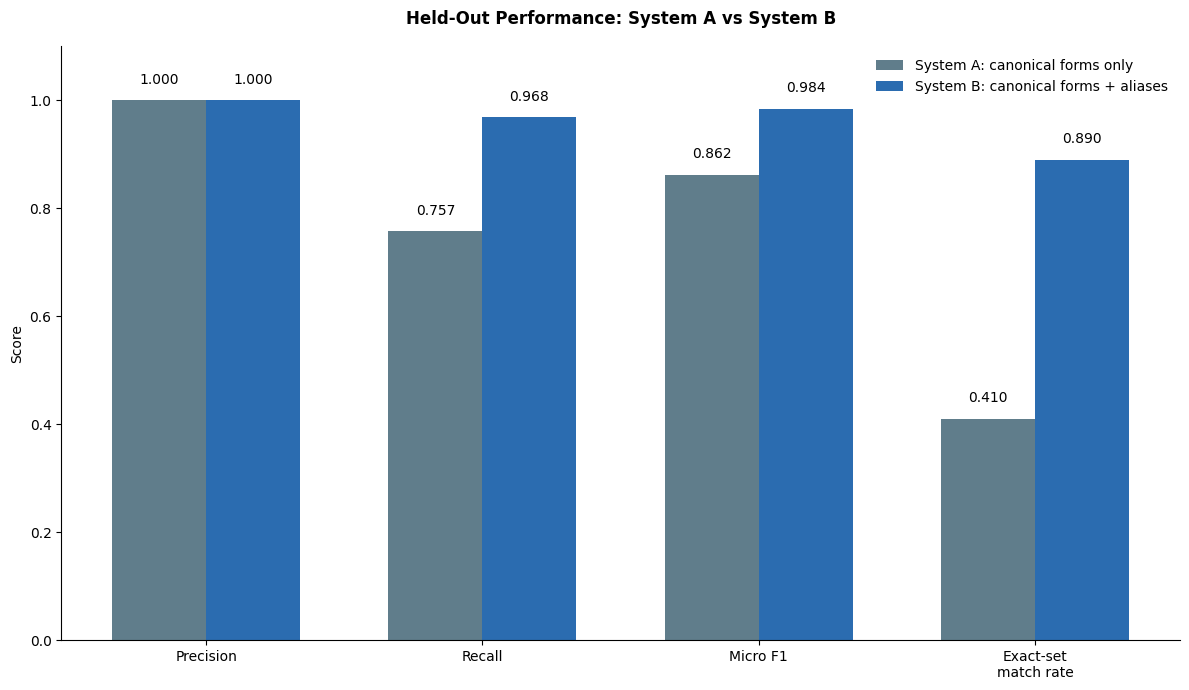

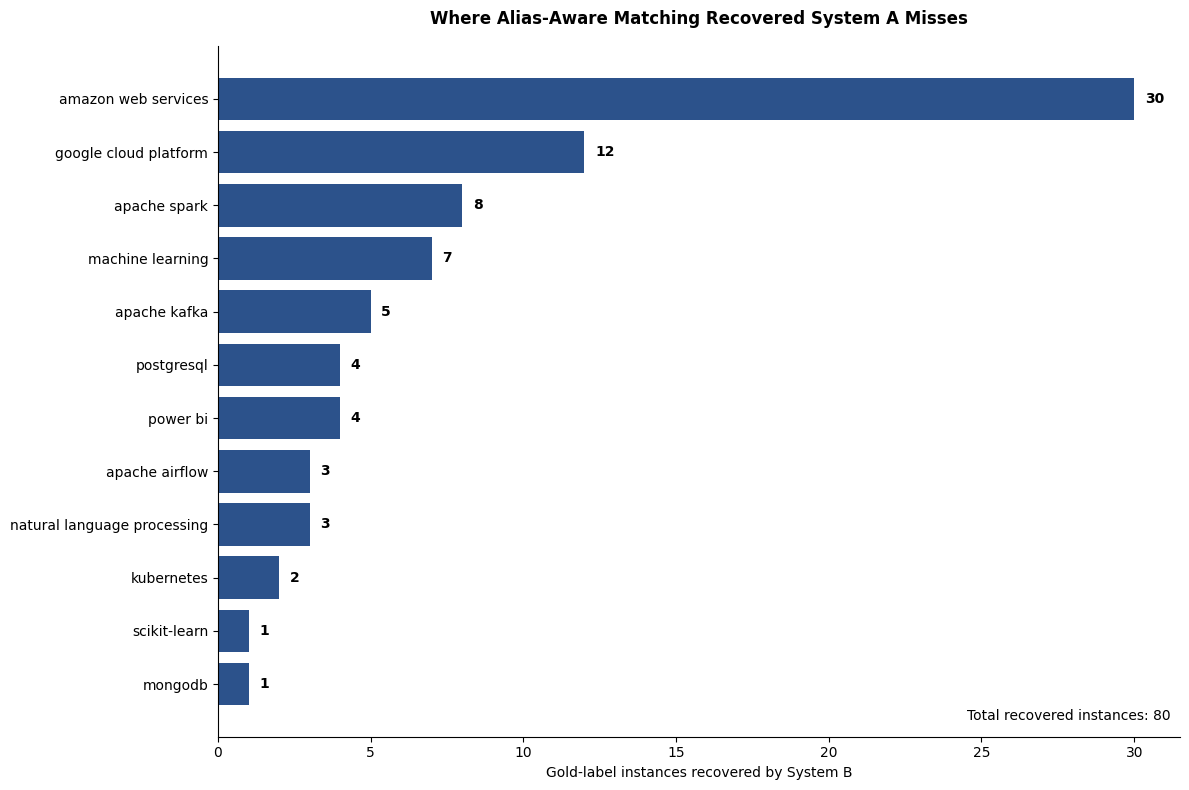

,Error family,Residual false-negative instances
0,Unapproved lexical variant or abbreviation,8
1,Conservative hyphen/boundary-policy block,2
2,Indirect related-technology reference,1
3,Compound or slash-separated expression,1


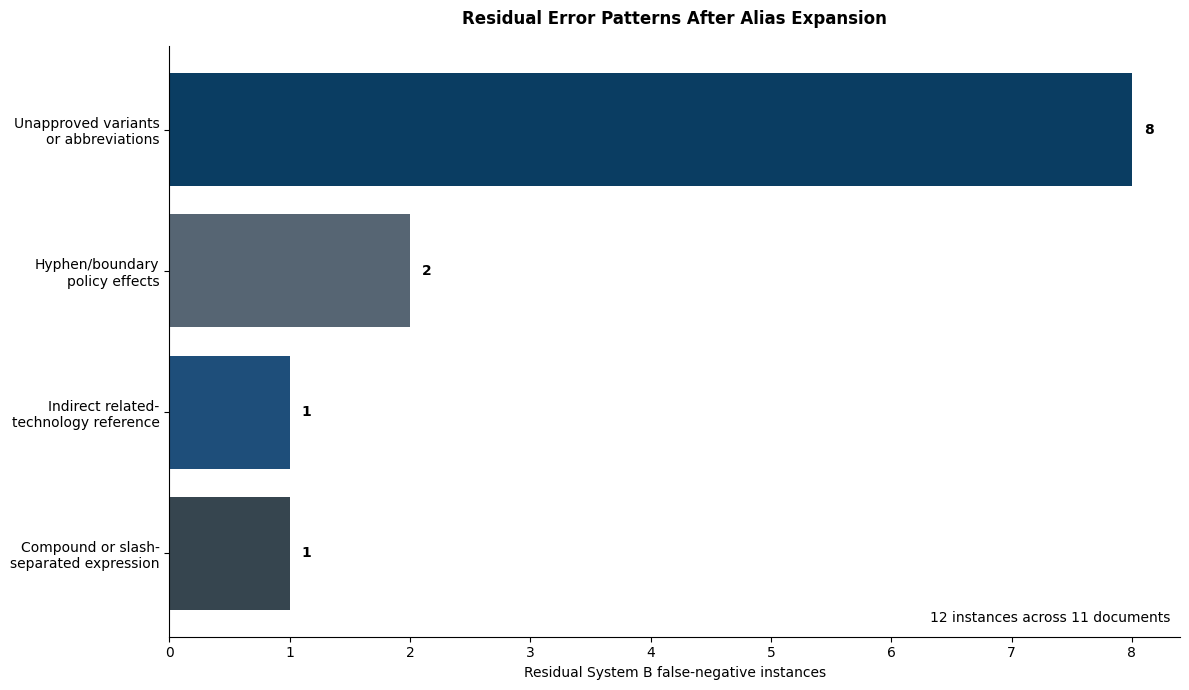

All final figures were created successfully.
Figure folder: /content/evaluationOutputs/figures


In [29]:
systemAColor = "#607D8B" # Dark blue-grey
systemBColor = "#2B6CB0" # Dark Blue
recoveryColor = "#2C528B" # Darker blue
errorColor = "#4A5568" # Dark grey
textColor = "#1F2937"


def saveFigure(
    figure,
    filename
):

    pngPath = figureFolder / (
        f"{filename}.png"
    )

    figure.savefig(
        pngPath,
        dpi=400,
        bbox_inches="tight",
        facecolor="white"
    )



figureOne, axisOne = plt.subplots(
    figsize=(12, 7)
)


metricNames = [
    "Micro precision",
    "Micro recall",
    "Micro F1",
    "Exact-set-match rate"
]

metricLabels = [
    "Precision",
    "Recall",
    "Micro F1",
    "Exact-set\nmatch rate"
]

metricPositions = list(
    range(
        len(metricNames)
    )
)

barWidth = 0.34


systemAValues = metricSummary.loc[
    metricSummary["System"].eq(
        "System A"
    ),
    metricNames
].iloc[0].tolist()

systemBValues = metricSummary.loc[
    metricSummary["System"].eq(
        "System B"
    ),
    metricNames
].iloc[0].tolist()


systemABars = axisOne.bar(
    [
        position - barWidth / 2
        for position in metricPositions
    ],
    systemAValues,
    width=barWidth,
    color=systemAColor,
    label="System A: canonical forms only"
)

systemBBars = axisOne.bar(
    [
        position + barWidth / 2
        for position in metricPositions
    ],
    systemBValues,
    width=barWidth,
    color=systemBColor,
    label="System B: canonical forms + aliases"
)


axisOne.set_ylim(
    0,
    1.10
)

axisOne.set_xticks(
    metricPositions
)

axisOne.set_xticklabels(
    metricLabels
)

axisOne.set_ylabel(
    "Score"
)

axisOne.set_title(
    "Held-Out Performance: System A vs System B",
    weight="bold",
    pad=16
)


axisOne.set_axisbelow(
    True
)

axisOne.spines[
    "top"
].set_visible(
    False
)

axisOne.spines[
    "right"
].set_visible(
    False
)

axisOne.legend(
    frameon=False,
    loc="upper right"
)


for bar in list(
    systemABars
) + list(
    systemBBars
):

    axisOne.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 0.025,

        f"{bar.get_height():.3f}",

        ha="center",
        va="bottom"
    )


figureOne.tight_layout()

saveFigure(
    figureOne,
    "MainPerformanceComparison"
)

plt.show()
plt.close(figureOne)


recoveryByLabel = perLabelMetrics[
    [
        "Canonical label",
        "Recovered by System B"
    ]
].copy()

recoveryByLabel = recoveryByLabel[
    recoveryByLabel[
        "Recovered by System B"
    ] > 0
].sort_values(
    "Recovered by System B"
)


figureTwo, axisTwo = plt.subplots(
    figsize=(12, 8)
)


recoveryBars = axisTwo.barh(
    recoveryByLabel[
        "Canonical label"
    ],

    recoveryByLabel[
        "Recovered by System B"
    ],

    color=recoveryColor
)


axisTwo.set_xlabel(
    "Gold-label instances recovered by System B"
)

axisTwo.set_title(
    "Where Alias-Aware Matching Recovered System A Misses",
    weight="bold",
    pad=16
)


axisTwo.set_axisbelow(
    True
)

axisTwo.spines[
    "top"
].set_visible(
    False
)

axisTwo.spines[
    "right"
].set_visible(
    False
)


for bar in recoveryBars:

    axisTwo.text(
        bar.get_width()
        + 0.35,

        bar.get_y()
        + bar.get_height() / 2,

        str(
            int(
                bar.get_width()
            )
        ),

        va="center",
        weight="bold"
    )


axisTwo.text(
    0.99,
    0.02,

    (
        "Total recovered instances: "
        f"{int(recoveryByLabel['Recovered by System B'].sum())}"
    ),

    transform=axisTwo.transAxes,
    ha="right",
    va="bottom"
)


figureTwo.tight_layout()

saveFigure(
    figureTwo,
    "AliasRecoveryByLabel"
)

plt.show()
plt.close(figureTwo)


errorFamilyNames = {
    "Unapproved lexical variant or abbreviation": (
        "Unapproved variants\nor abbreviations"
    ),

    "Conservative hyphen/boundary-policy block": (
        "Hyphen/boundary\npolicy effects"
    ),

    "Indirect related-technology reference": (
        "Indirect related-\ntechnology reference"
    ),

    "Compound or slash-separated expression": (
        "Compound or slash-\nseparated expression"
    )
}


residualSummary = residualErrorRecord[
    "Error family"
].value_counts().rename_axis(
    "Error family"
).reset_index(
    name="Residual FN instances"
)


residualSummary["Display label"] = residualSummary[
    "Error family"
].map(
    errorFamilyNames
)


assert residualSummary[
    "Display label"
].notna().all(), (
    "Every residual error family must have "
    "a display label."
)


residualSummary = residualSummary.sort_values(
    "Residual FN instances"
)


figureThree, axisThree = plt.subplots(
    figsize=(12, 7)
)


errorBars = axisThree.barh(
    residualSummary[
        "Display label"
    ],

    residualSummary[
        "Residual FN instances"
    ],
        color=[
        "#36454F", # Deep Charcoal
        "#1E4E7A", # Ocean Blue
        "#566573", # Slate Grey
        "#0A3D62"  # Navy Blue
    ]
)


axisThree.set_xlabel(
    "Residual System B false-negative instances"
)

axisThree.set_title(
    "Residual Error Patterns After Alias Expansion",
    weight="bold",
    pad=16
)


axisThree.set_axisbelow(
    True
)

axisThree.spines[
    "top"
].set_visible(
    False
)

axisThree.spines[
    "right"
].set_visible(
    False
)


for bar in errorBars:

    axisThree.text(
        bar.get_width()
        + 0.10,

        bar.get_y()
        + bar.get_height() / 2,

        str(
            int(
                bar.get_width()
            )
        ),

        va="center",
        weight="bold"
    )


axisThree.text(
    0.99,
    0.02,

    (
        f"{int(residualSummary['Residual FN instances'].sum())} "
        "instances across 11 documents"
    ),

    transform=axisThree.transAxes,
    ha="right",
    va="bottom"
)


figureThree.tight_layout()

saveFigure(
    figureThree,
    "ResidualErrorPatterns"
)

residualCategorySummary = residualErrorRecord[
    "Error family"
].value_counts().rename_axis(
    "Error family"
).reset_index(
    name="Residual false-negative instances"
)


display(
    residualCategorySummary
)

plt.show()
plt.close(figureThree)


print(
    "All final figures were created successfully."
)

print(
    f"Figure folder: {figureFolder}"
)

## Interpretation and Limitations

System B increased held-out micro recall, micro F1, and exact-set-match rate
while both systems had the same observed micro precision.

System B recovered 80 of the 92 canonical-label instances missed by strict
canonical matching. The remaining 12 System B false-negative instances mainly
reflect unapproved variants or abbreviations and the deliberately conservative
hyphen-boundary policy.

The findings apply to the fixed 20-label inventory and the selected English
data-related IT job-description population. They do not establish that aliases
are universally safe, that all technical skills have been extracted, or that
the results automatically generalise to other datasets or labour markets.